### Basic Setups

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Parameter
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import random
import os
from PIL import Image
from torchvision import tv_tensors
from tqdm import tqdm
import matplotlib.patches as patches
import torch.optim as optim
from torchmetrics.detection import MeanAveragePrecision
import gc
import pandas as pd

In [2]:
Device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using",Device)

Using cuda


In [3]:
Seed = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(Seed)

### Data Preprocessing

In [4]:
DataRoot = "Detection Dataset 3 Class/YOLO TXT/Master Dataset"
BatchSize = 32

Mean = (0.4914, 0.4822, 0.4465)
Std = (0.2023, 0.1994, 0.2010)

classes = ('background', 'car', 'heavy_vehicle', 'motorcycle')

In [5]:
TrainTF = v2.Compose([
    v2.Resize((32, 32)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomAffine(degrees=0, scale=(0.2, 0.8), translate=(0.1, 0.1)),
    v2.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    v2.ToImage(), 
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(Mean, Std)
])

ValTF = v2.Compose([
    v2.Resize((32, 32)),         
    v2.ToImage(),               
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(Mean, Std)
])

In [6]:
class YOLOProjectDataset(Dataset):
    def __init__(self, ImageFolder, LabelFolder, Transform):
        self.ImageFolder = ImageFolder
        self.LabelFolder = LabelFolder
        self.Transform = Transform
        self.ImageNames = [f for f in os.listdir(ImageFolder) if f.endswith(('.jpg', '.png'))]

    def __len__(self): return len(self.ImageNames)

    def __getitem__(self, idx):
        ImgPath = os.path.join(self.ImageFolder, self.ImageNames[idx])
        LabelPath = os.path.join(self.LabelFolder, self.ImageNames[idx].rsplit('.', 1)[0] + '.txt')
        
        img = Image.open(ImgPath).convert("RGB")
        
        TargetClasses = 0
        TargetBoxes = torch.zeros(4)
        
        if os.path.exists(LabelPath):
            with open(LabelPath, 'r') as f:
                line = f.readline().split()
                if line:
                    TargetClasses = int(line[0]) 
                    TargetBoxes = torch.tensor([float(x) for x in line[1:5]])

        if self.Transform: img = self.Transform(img)
            
        return img, TargetClasses, TargetBoxes

### CNN Architecture

In [7]:
class ShuffleAttention(nn.Module):
    def __init__(self, channel, groups=8):
        super(ShuffleAttention, self).__init__()
        self.groups = groups
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.cweight = Parameter(torch.zeros(1, channel // (2 * groups), 1, 1))
        self.cbias = Parameter(torch.ones(1, channel // (2 * groups), 1, 1))
        self.sweight = Parameter(torch.zeros(1, channel // (2 * groups), 1, 1))
        self.sbias = Parameter(torch.ones(1, channel // (2 * groups), 1, 1))

        self.sigmoid = nn.Sigmoid()
        self.gn = nn.GroupNorm(channel // (2 * groups), channel // (2 * groups))

    @staticmethod
    def channel_shuffle(x, groups):
        b, c, h, w = x.shape

        x = x.reshape(b, groups, -1, h, w)
        x = x.permute(0, 2, 1, 3, 4)

        x = x.reshape(b, -1, h, w)

        return x

    def forward(self, x):
        b, c, h, w = x.shape

        x = x.reshape(b * self.groups, -1, h, w)
        x_0, x_1 = x.chunk(2, dim=1)

        xn = self.avg_pool(x_0)
        xn = self.cweight * xn + self.cbias
        xn = x_0 * self.sigmoid(xn)

        xs = self.gn(x_1)
        xs = self.sweight * xs + self.sbias
        xs = x_1 * self.sigmoid(xs)

        out = torch.cat([xn, xs], dim=1)
        out = out.reshape(b, -1, h, w)

        out = self.channel_shuffle(out, 2)
        return out

In [8]:
class ConvolutionalNeuralNetwork(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.ConvolutionBlocks = nn.Sequential(
            
            # ================================== Block I ==================================
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), # Second Conv
            nn.BatchNorm2d(32),
            nn.ReLU(),
            ShuffleAttention(32),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),
            
            # ================================== Block II ==================================
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), # Second Conv
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ShuffleAttention(64),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),
            
            # ================================== Block III ==================================
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), # Second Conv
            nn.BatchNorm2d(128),
            nn.ReLU(),
            ShuffleAttention(128),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),

            # ================================== Block IV ==================================
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            ShuffleAttention(256),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),
            
            # ================================== Block V ==================================
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            ShuffleAttention(512),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        self.flatten = nn.Flatten()

        self.classifier = nn.Sequential(
            nn.Linear(512 * 1 * 1, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

        self.bbox = nn.Sequential(
            nn.Linear(512 * 1 * 1, 256),
            nn.ReLU(),
            nn.Linear(256, 4),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.ConvolutionBlocks(x)
        x = self.flatten(x)

        ClassLogits = self.classifier(x)
        BoundingBoxCoordinates = self.bbox(x)
            
        return ClassLogits, BoundingBoxCoordinates

CNN = ConvolutionalNeuralNetwork().to(Device)

### Optimizer and Criterion

In [9]:
ClassificationLoss = nn.CrossEntropyLoss()

CoordinatesLoss = nn.SmoothL1Loss() 

def IntersectionOverUnion(box1, box2):
    b1_x1, b1_y1 = box1[:, 0] - box1[:, 2]/2, box1[:, 1] - box1[:, 3]/2
    b1_x2, b1_y2 = box1[:, 0] + box1[:, 2]/2, box1[:, 1] + box1[:, 3]/2
    b2_x1, b2_y1 = box2[:, 0] - box2[:, 2]/2, box2[:, 1] - box2[:, 3]/2
    b2_x2, b2_y2 = box2[:, 0] + box2[:, 2]/2, box2[:, 1] + box2[:, 3]/2

    inter_x1 = torch.max(b1_x1, b2_x1)
    inter_y1 = torch.max(b1_y1, b2_y1)
    inter_x2 = torch.min(b1_x2, b2_x2)
    inter_y2 = torch.min(b1_y2, b2_y2)
    
    inter_area = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)

    b1_area = (b1_x2 - b1_x1) * (b1_y2 - b1_y1)
    b2_area = (b2_x2 - b2_x1) * (b2_y2 - b2_y1)
    
    return torch.mean(inter_area / (b1_area + b2_area - inter_area + 1e-6))

### Training and Evaluation

In [17]:
def TrainingAndEvaluation(FoldIndex, Model, TrainingSet, ValidationSet, Device, Optimizer, mAP_50, Epochs = 20):
    best_v_map = 0.0
    
    mAP_50 = mAP_50.to(Device)

    history = {
        'train_loss': [], 
        'val_loss': [],
        'train_cls_acc': [], 
        'val_cls_acc': [],
        'val_iou': [],
        'val_precision': [],
        'val_recall': [],
        'val_mAP': []
    }

    print(f"{'Epoch':>8} {'GPU_mem':>10} {'box_loss':>10} {'cls_loss':>10} {'total':>10} {'IoU':>10} {'mAP@50':>10}")

    for epoch in range(Epochs):
        Model.train()
        t_loss, t_cls_err, t_box_err = 0, 0, 0
        correct, total = 0, 0
        
        pbar = tqdm(TrainingSet, desc=f"Epoch {epoch+1}/{Epochs}", leave=False)
        for imgs, labels, boxes in pbar:
            imgs, labels, boxes = imgs.to(Device), labels.to(Device), boxes.to(Device)
            
            out_cls, out_box = Model(imgs)

            loss_cls = ClassificationLoss(out_cls, labels)
            loss_box = CoordinatesLoss(out_box, boxes)
            total_loss = loss_cls + (5.0 * loss_box)

            Optimizer.zero_grad()
            total_loss.backward()
            Optimizer.step()

            t_loss += total_loss.item()
            t_cls_err += loss_cls.item()
            t_box_err += loss_box.item()
            _, predicted = torch.max(out_cls.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            pbar.set_postfix(loss=f"{total_loss.item():.4f}")

        Model.eval()
        v_loss, v_iou = 0, 0
        v_correct, v_total = 0, 0
        mAP_50.reset()

        with torch.no_grad():
            val_pbar = tqdm(ValidationSet, desc=f"Validating Epoch {epoch+1}/{Epochs}", leave=False)

            for imgs, labels, boxes in val_pbar:
                imgs, labels, boxes = imgs.to(Device), labels.to(Device), boxes.to(Device)
                out_cls, out_box = Model(imgs)
                
                v_loss += (ClassificationLoss(out_cls, labels) + 5.0 * CoordinatesLoss(out_box, boxes)).item()
                probs = torch.softmax(out_cls, dim=1)
                scores, pred = torch.max(probs, dim=1)
                v_total += labels.size(0)
                v_correct += (pred == labels).sum().item()
                v_iou += IntersectionOverUnion(out_box, boxes)

                preds_list = [{'boxes': out_box[i].unsqueeze(0), 'scores': scores[i].unsqueeze(0), 'labels': pred[i].unsqueeze(0)} for i in range(imgs.shape[0])]
                target_list = [{'boxes': boxes[i].unsqueeze(0), 'labels': labels[i].unsqueeze(0)} for i in range(imgs.shape[0])]
                mAP_50.update(preds_list, target_list)

        mAP_results = mAP_50.compute()
        gpu_mem = f"{torch.cuda.memory_reserved() / 1E9:.2f}G"
        avg_t_loss = t_loss / len(TrainingSet)
        avg_v_loss = v_loss / len(ValidationSet)
        avg_iou = v_iou / len(ValidationSet)
        current_map = mAP_results['map_50'].item()
        
        print(f"{epoch+1:>8} {gpu_mem:>10} "
            f"{t_box_err/len(TrainingSet):>10.4f} "
            f"{t_cls_err/len(TrainingSet):>10.4f} "
            f"{avg_t_loss:>10.4f} "
            f"{avg_iou:>10.4f} "
            f"{mAP_results['map_50']:>10.4f}")
        
        if current_map > best_v_map:
            best_v_map = current_map
            torch.save(Model.state_dict(), f'Best_Baseline_Fold_{FoldIndex+1}.pth')

        history['train_loss'].append(avg_t_loss)
        history['val_loss'].append(avg_v_loss)
        history['train_cls_acc'].append(100 * correct / total)
        history['val_cls_acc'].append(100 * v_correct / v_total)
        history['val_iou'].append(avg_iou.item())
        history['val_mAP'].append(mAP_results['map_50'].item())
        history['val_precision'].append(mAP_results['mar_1'].item())
        history['val_recall'].append(mAP_results['mar_10'].item())

    return Model, history

In [19]:
TestFolder = "Camera di tengah Satu Arah Banyak"
CrossValidationFolder = [
    "CCTV Lalu Lintas Surabaya", 
    "Highway CCTV", 
    "Jalan Rame", 
    "Multi Tracking", 
    "VEHICLE"
]
DatasetPath = "Detection Dataset 3 Class/YOLO TXT"

TestingData = YOLOProjectDataset(
    os.path.join(DatasetPath, TestFolder, "train/images"),
    os.path.join(DatasetPath, TestFolder, "train/labels"),
    ValTF
)
TestingSet = DataLoader(TestingData, batch_size=BatchSize, shuffle=False)

FoldResult = []

for fold in range(len(CrossValidationFolder)):
    print(f"\n=============================== STARTING FOLD {fold + 1} ===============================")
    
    ValidationFolderName = CrossValidationFolder[fold]
    TrainingFolderName = [folder for folder in CrossValidationFolder if folder != ValidationFolderName]
    
    print(f"Validation Folder: {ValidationFolderName}")
    print(f"Training Folders: {TrainingFolderName}\n")

    TrainingDatasets = []

    for FolderName in TrainingFolderName:

        TrainingDatasets.append(YOLOProjectDataset(
            os.path.join(DatasetPath, FolderName, "train/images"),
            os.path.join(DatasetPath, FolderName, "train/labels"),
            TrainTF
        ))
        
    TrainingData = torch.utils.data.ConcatDataset(TrainingDatasets)
    
    ValidationData = YOLOProjectDataset(
        os.path.join(DatasetPath, ValidationFolderName, "train/images"),
        os.path.join(DatasetPath, ValidationFolderName, "train/labels"),
        ValTF
    )

    TrainingSet = DataLoader(TrainingData, batch_size=BatchSize, shuffle=True)
    ValidationSet = DataLoader(ValidationData, batch_size=BatchSize, shuffle=False)

    CNNFold = ConvolutionalNeuralNetwork().to(Device)
    OptimizerFold = optim.Adam(CNNFold.parameters(), lr=1e-4)
    mAP50 = MeanAveragePrecision(box_format='cxcywh')

    TrainedModel, history = TrainingAndEvaluation(fold, CNNFold, TrainingSet, ValidationSet, Device, OptimizerFold, mAP50)

    FoldResult.append(history)
    torch.save(TrainedModel.state_dict(), f'Baseline_Fold_{fold+1}.pth')

    del CNNFold, OptimizerFold, mAP50
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Fold {fold+1} cleanup complete.")

print("\nCROSS VALIDATION COMPLETE.")


=============================== STARTING FOLD 1 ===============================
Validation Folder: CCTV Lalu Lintas Surabaya
Training Folders: ['Highway CCTV', 'Jalan Rame', 'Multi Tracking', 'VEHICLE']

   Epoch    GPU_mem   box_loss   cls_loss      total        IoU     mAP@50


       1      0.47G     0.0174     1.0171     1.1042     0.0612     0.0001


       2      0.47G     0.0150     0.9442     1.0194     0.0599     0.0001


       3      0.47G     0.0150     0.8993     0.9742     0.0541     0.0001


       4      0.47G     0.0148     0.8616     0.9357     0.0533     0.0000


...

      16      0.35G     0.0122     0.8605     0.9218     0.0393     0.0001


      17      0.35G     0.0122     0.8524     0.9134     0.0403     0.0001


      18      0.35G     0.0122     0.8544     0.9153     0.0472     0.0000


      19      0.35G     0.0122     0.8456     0.9067     0.0424     0.0000


      20      0.35G     0.0121     0.8436     0.9044     0.0392     0.0002
Fold 5 cleanup complete.

CROSS VALIDATION COMPLETE.


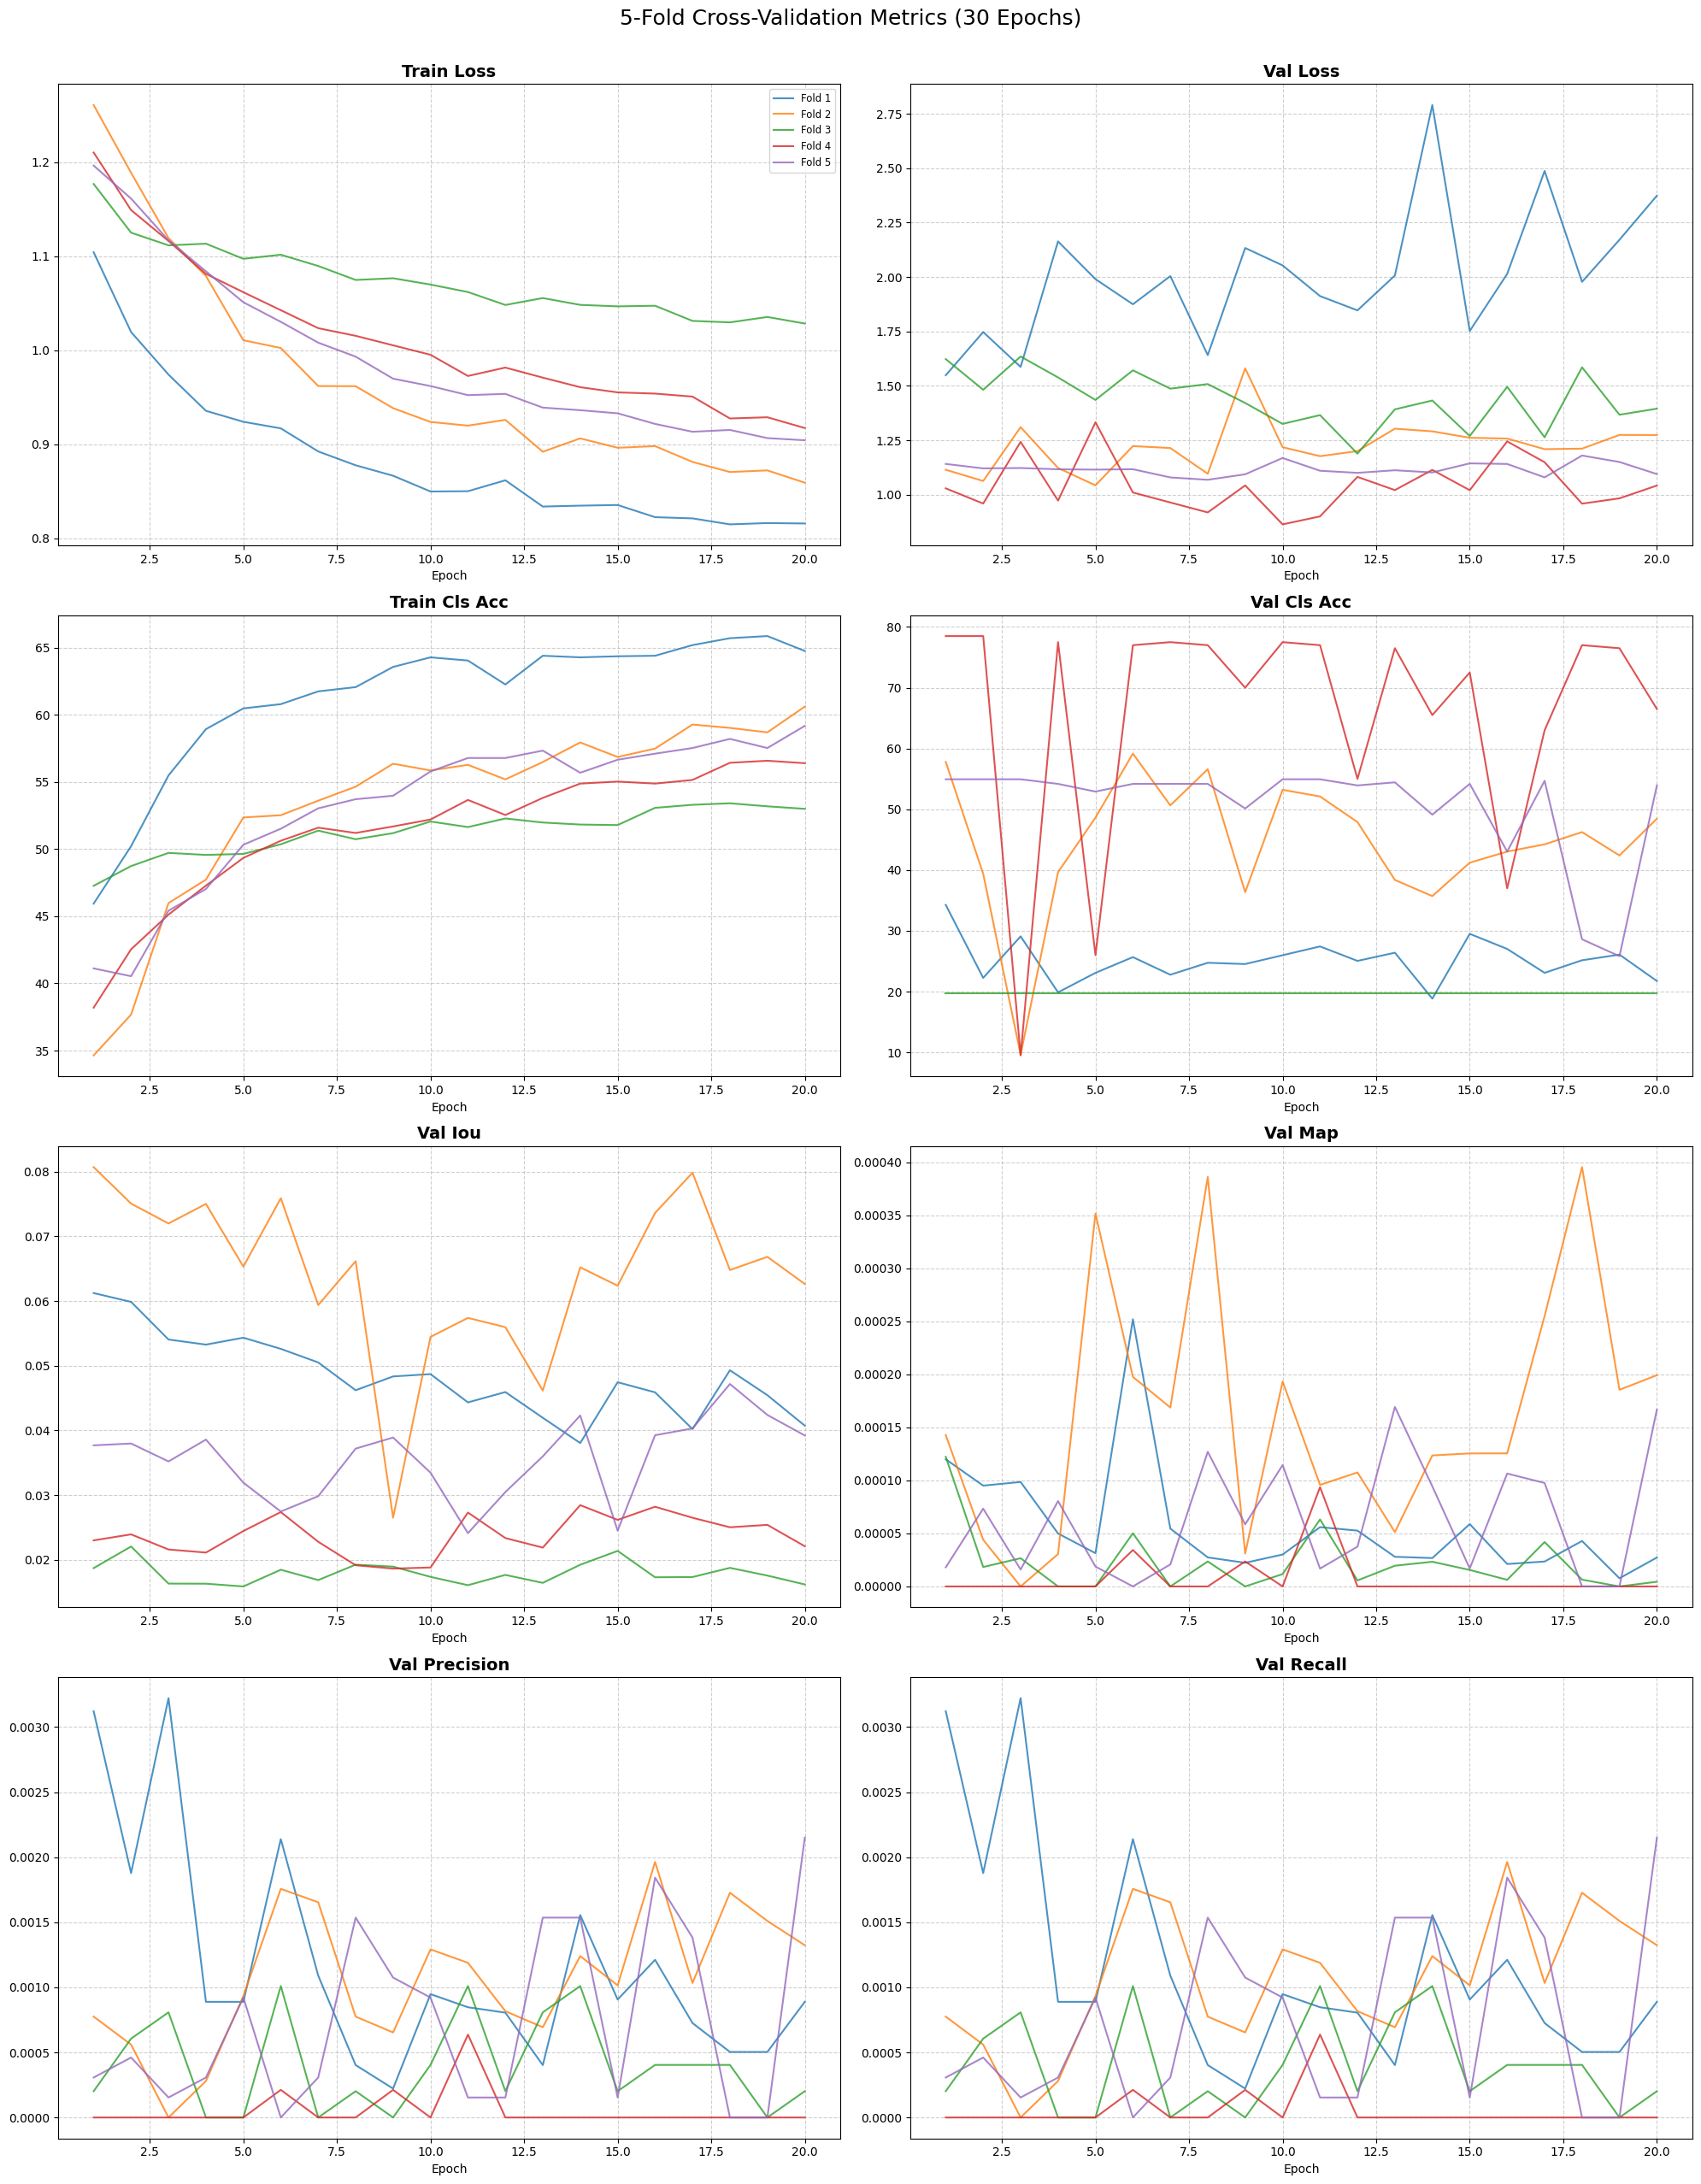

In [24]:
metrics = [
    'train_loss', 'val_loss', 
    'train_cls_acc', 'val_cls_acc', 
    'val_iou', 'val_mAP', 
    'val_precision', 'val_recall'
]

fig, axes = plt.subplots(4, 2, figsize=(20, 25))
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    for fold_idx, history in enumerate(FoldResult):
        epochs = range(1, len(history[metric]) + 1)
        ax.plot(epochs, history[metric], 
                label=f'Fold {fold_idx+1}', 
                color=colors[fold_idx], 
                alpha=0.8, linewidth=1.5)
    
    ax.set_title(metric.replace('_', ' ').title(), fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    if i == 0:
        ax.legend(loc='best', fontsize='small')

plt.tight_layout()
plt.suptitle('5-Fold Cross-Validation Metrics (30 Epochs)', fontsize=18, y=1.02)
plt.show()

In [26]:
def Summarize(FoldResults):
    Summary = []

    for i, history in enumerate(FoldResults):
        Peak_mAP = max(history['val_mAP'])
        PeakIoU = max(history['val_iou'])
        LowestLoss = min(history['val_loss'])
        PeakAcc = max(history['val_cls_acc'])
        
        Summary.append({
            'Fold': i + 1,
            'Best mAP@50': Peak_mAP,
            'Best IoU': PeakIoU,
            'Min Val Loss': LowestLoss,
            'Max Acc (%)': PeakAcc
        })

    df = pd.DataFrame(Summary)

    Means = df.mean(numeric_only=True).drop('Fold')
    StandardDeviations = df.std(numeric_only=True).drop('Fold')

    print("\n" + "="*50)
    print("      CROSS-VALIDATION PEAK PERFORMANCE")
    print("="*50)
    print(df.to_string(index=False, formatters={
        'Best mAP@50': '{:,.4f}'.format,
        'Best IoU': '{:,.4f}'.format,
        'Min Val Loss': '{:,.4f}'.format,
        'Max Acc (%)': '{:,.2f}%'.format
    }))
    
    print("-" * 50)
    
    print("FINAL SUMMARY (Mean ± Std Dev):")
    for metric in Means.index:
        unit = "%" if "Acc" in metric else ""
        print(f"{metric:<15}: {Means[metric]:.4f} ± {StandardDeviations[metric]:.4f}{unit}")
    print("="*50)

Summarize(FoldResult)


      CROSS-VALIDATION PEAK PERFORMANCE
 Fold Best mAP@50 Best IoU Min Val Loss Max Acc (%)
    1      0.0003   0.0612       1.5488      34.27%
    2      0.0004   0.0807       1.0429      59.16%
    3      0.0001   0.0221       1.1886      19.69%
    4      0.0001   0.0285       0.8637      78.50%
    5      0.0002   0.0472       1.0685      54.94%
--------------------------------------------------
FINAL SUMMARY (Mean ± Std Dev):
Best mAP@50    : 0.0002 ± 0.0001
Best IoU       : 0.0479 ± 0.0240
Min Val Loss   : 1.1425 ± 0.2551
Max Acc (%)    : 49.3098 ± 22.8276%


### Testing

In [37]:
def Testing(img_path, model, transform, device, classes):
    model.eval()

    raw_img = Image.open(img_path).convert("RGB")
    w, h = raw_img.size
    
    input_tensor = transform(raw_img, None)[0].unsqueeze(0).to(device)

    with torch.no_grad():
        out_cls, out_box = model(input_tensor)
        
        probs = F.softmax(out_cls, dim=1)
        conf, pred_idx = torch.max(probs, 1)

    box = out_box.squeeze().cpu().numpy() 
    conf_score = conf.item()
    class_name = classes[pred_idx.item()]

    real_cx, real_cy = box[0] * w, box[1] * h
    real_w, real_h = box[2] * w, box[3] * h
    
    x1 = max(0, real_cx - (real_w / 2))
    y1 = max(0, real_cy - (real_h / 2))
    
    rect_w = min(w - x1, real_w)
    rect_h = min(h - y1, real_h)

    plt.figure(figsize=(10, 6))
    plt.imshow(raw_img)
    ax = plt.gca()
    
    rect = patches.Rectangle((x1, y1), rect_w, rect_h, linewidth=3, 
                             edgecolor='#00FF00', facecolor='none')
    ax.add_patch(rect)
    
    label_text = f"{class_name}: {conf_score:.2%}"
    plt.text(x1, y1 - 10, label_text, color='white', fontweight='bold',
             bbox=dict(facecolor='#00FF00', alpha=0.8, pad=2, edgecolor='none'))
    
    plt.title(f"Baseline Prediction - {os.path.basename(img_path)}", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

C:\Users\justi\AppData\Local\Temp\ipykernel_33608\1632526161.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  BestModel.load_state_dict(torch.load(WeightModelPath, map_lo

Successfully loaded weights from Best_Baseline_Fold_2.pth


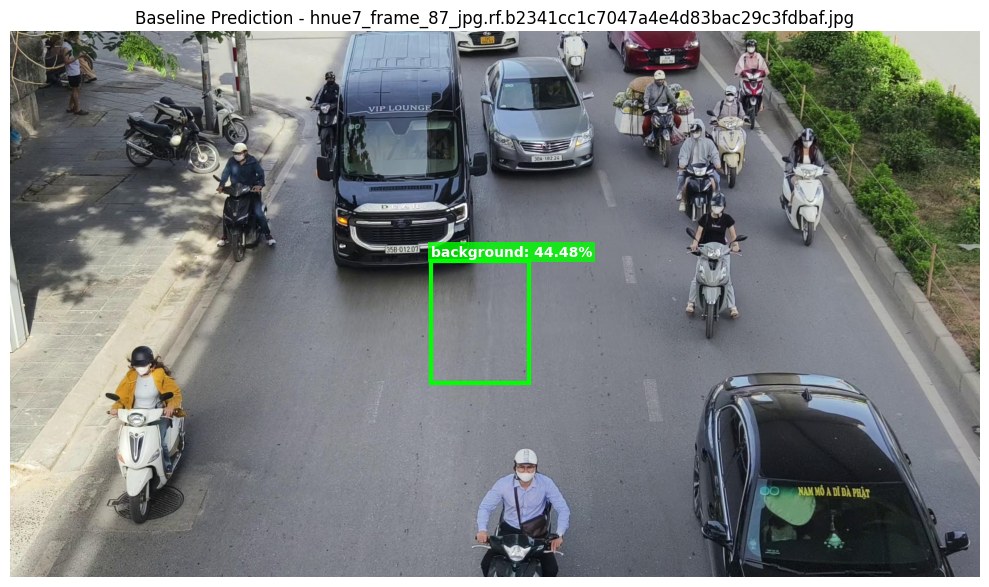

In [39]:
BestModel = CNN.to(Device) 

WeightModelPath = 'Best_Baseline_Fold_2.pth' 
BestModel.load_state_dict(torch.load(WeightModelPath, map_location=Device))

BestModel.eval()

print(f"Successfully loaded weights from {WeightModelPath}")

TestImagePath = os.path.join(DatasetPath, TestFolder, 'train/images', TestingData.ImageNames[random.randint(0, 100)])
Testing(TestImagePath, BestModel, ValTF, Device, classes)